# Day 15 — Ensemble Methods: Stacking, Voting, and Blending
## Week 2: Ensemble Methods | Digital Consumer Platform Analytics

---

### Learning Objectives
- Understand stacking architecture — Level-0 and Level-1 models
- Derive why OOF predictions prevent leakage in stacking
- Understand the diversity principle — why different model types stack better
- Compare: Hard voting vs Soft voting vs Blending vs Stacking
- Know when stacking beats individual models — and when it doesn't

---

### Dataset
**Telco Churn** — final ensemble theory day before practice.

---

## Part 1: Theory

### 15.1 Voting

The simplest ensemble: combine predictions by vote.

**Hard voting:** Each model predicts a class label. Final prediction = majority vote.
$$\hat{y} = \text{mode}(\hat{y}_1, \hat{y}_2, ..., \hat{y}_M)$$

**Soft voting:** Each model predicts class probabilities. Final prediction = average probability.
$$\hat{p} = \frac{1}{M} \sum_m \hat{p}_m(x)$$

**When soft > hard:** When models are well-calibrated (probabilities reflect real frequencies). Soft voting uses more information (probability magnitude, not just direction).

**When hard > soft:** When one model is poorly calibrated but directionally correct.

**Limitation:** Voting weights each model equally — doesn't account for model quality.

---

### 15.2 Blending

Train each Level-0 model on the full training set. Hold out a validation set (typically 20%). Train the Level-1 meta-learner on Level-0 predictions on the validation set.

```
Training data (80%) → fit Level-0 models
Validation data (20%) → Level-0 predictions → fit Level-1 meta-learner
Test data → Level-0 predictions → Level-1 prediction
```

**Simple and fast.** But wastes 20% of training data for the Level-0 models.

**Leakage risk:** If Level-0 models were trained on training data and Level-1 is trained on validation data predictions, there's no leakage. But if you accidentally use training data predictions to train Level-1 — Level-0 models have seen that data and predictions are overly optimistic.

---

### 15.3 Stacking — OOF Predictions

**Problem with blending:** Level-0 models are only trained on 80% of data. Level-1 only sees 20% of data for training.

**Solution:** Use cross-validation to generate Level-1 training data that:
1. Comes from the full training set
2. Was never seen by the Level-0 model making that prediction

**Out-of-Fold (OOF) stacking:**

```
For k = 1 to K folds:
    Train Level-0 models on all folds except fold k
    Generate predictions on fold k (OOF predictions)

After all folds: concatenate OOF predictions → full Level-1 training set
Train Level-1 meta-learner on OOF predictions
```

**Why no leakage:** Each fold-k prediction was made by a model that never saw fold-k data.

**Comparison:**

| Method | Level-0 training data | Level-1 training data | Data efficiency |
|--------|----------------------|----------------------|----------------|
| Voting | Full train | N/A | High |
| Blending | 80% train | 20% validation | Medium |
| OOF Stacking | Full train (via CV) | Full train (OOF) | High |

---

### 15.4 The Diversity Principle

Stacking gains most when Level-0 models are diverse — they make different kinds of errors.

**High diversity:** Logistic Regression + Random Forest + LightGBM + KNN
- LR: linear decision boundary, calibrated probabilities
- RF: non-linear, high variance, good with interactions
- LightGBM: non-linear, gradient-based, handles large data
- KNN: instance-based, very different error pattern

**Low diversity:** RF + ExtraTrees + BaggingClassifier
- All tree-based, all bagging-based
- Highly correlated errors → stacking adds little

**Measuring diversity:** Average pairwise correlation of OOF predictions. Below 0.85 is meaningful diversity. Above 0.95 means stacking will not help.

---

### 15.5 Meta-Learner Selection

The Level-1 meta-learner learns when to trust each Level-0 model.

**Logistic Regression (most common):**
- Learns linear combination of Level-0 predictions
- Interpretable: positive coefficients = trust this model
- Low variance — prevents overfitting on limited Level-1 data
- Add `use_features_in_secondary=True` to also include original features

**Ridge Regression:** Like LR but for regression tasks. Regularization prevents extreme weights.

**LightGBM as meta-learner:** More powerful but higher variance risk. Use only with many training examples.

**Rule:** Start with Logistic Regression for classification, Ridge for regression. Only use more complex meta-learners with > 10K training examples.

---

### 15.6 When Stacking Helps

✅ **Stacking helps when:**
- Level-0 models are diverse (different algorithms, different error patterns)
- You have enough data that OOF folds are meaningful
- Models have complementary strengths on different subsets of data
- Calibrated probabilities are important (meta-learner recalibrates)

❌ **Stacking doesn't help when:**
- Models are highly correlated (similar algorithms, similar features)
- Dataset is small (OOF predictions have high variance)
- One model clearly dominates all others on all metrics
- Computation budget is tight (stacking = K × M model fits)

---

## Part 2: Practice

---

In [2]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [3]:
DATA_PATH = r'C:\Users\user\datasets\telco\telco.csv'
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df = df.drop(columns=['customerID'], errors='ignore')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = (df['Churn'].str.strip() == 'Yes').astype(int)

display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [5]:
# ── Q1: Hard vs soft voting comparison ────────────────────────────────────
# Build a VotingClassifier with 4 diverse models:
#   LogisticRegression, RandomForest, LightGBM, KNN
# Compare:
#   A: Hard voting
#   B: Soft voting
#   C: Best individual model (from 5-fold CV)
# Metric: 5-fold CV AUC
# Does soft voting beat hard voting? Does either beat the best individual?
# Measure diversity: compute pairwise correlation of predicted probabilities

from sklearn.model_selection import train_test_split

# ── Preprocessing: impute + encode + scale (LR/KNN need scaling; RF/LightGBM don't care) ─
numeric_cols = df.drop(columns=['Churn']).select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.drop(columns=['Churn']).select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), categorical_cols),
])

X_raw = df.drop(columns=['Churn'])
y = df['Churn'].values
X_unscaled = preprocessor.fit_transform(X_raw)
X = StandardScaler().fit_transform(X_unscaled)   # scale the WHOLE output — harmless for trees

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=420
)

# One technical wrinkle worth flagging up front: 
# VotingClassifier(voting='hard') only outputs discrete class labels — it has no predict_proba, 
# so there's no real probability ranking to compute a proper AUC curve from. 
# roc_auc_score can technically accept binary 0/1 predictions 
# instead of probabilities, but that collapses AUC down to a single operating point (equivalent to balanced accuracy) 
# rather than a true ranking-curve metric — a different, less informative kind of "AUC" than what soft voting gives you. 
# I'm computing it anyway since that's what the spec is asking for, 
# but the comparison isn't perfectly apples-to-apples conceptually — 
# worth keeping in mind when interpreting "does soft beat hard."

# ── The 4 diverse Level-0 models ────────────────────────────────────────────
models_q1 = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=420),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=420, verbose=-1),
    'KNN': KNeighborsClassifier(n_neighbors=15),
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# ── C: Best individual model ────────────────────────────────────────────────
individual_aucs = {}
for name, model in models_q1.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv5, scoring='roc_auc')
    individual_aucs[name] = scores.mean()

best_individual_name = max(individual_aucs, key=individual_aucs.get)
print("Individual model AUCs:")
for name, auc in individual_aucs.items():
    print(f"  {name}: {auc:.4f}")
print(f"Best individual: {best_individual_name} ({individual_aucs[best_individual_name]:.4f})")

# ── B: Soft voting (proper AUC via predict_proba) ───────────────────────────
voting_soft = VotingClassifier(estimators=list(models_q1.items()), voting='soft')
soft_scores = cross_val_score(voting_soft, X_train, y_train, cv=cv5, scoring='roc_auc')
print(f"\nSoft voting AUC: {soft_scores.mean():.4f}")

# ── A: Hard voting (degenerate AUC from binary predictions — see note above) ─
voting_hard = VotingClassifier(estimators=list(models_q1.items()), voting='hard')
hard_oof_preds = cross_val_predict(voting_hard, X_train, y_train, cv=cv5, method='predict')
hard_auc = roc_auc_score(y_train, hard_oof_preds)
print(f"Hard voting AUC (degenerate — single operating point, not a full curve): {hard_auc:.4f}")

# ── Diversity: pairwise correlation of OOF predicted probabilities ─────────
oof_probas = {}
for name, model in models_q1.items():
    oof_probas[name] = cross_val_predict(model, X_train, y_train, cv=cv5, method='predict_proba')[:, 1]

proba_df = pd.DataFrame(oof_probas)
corr_matrix = proba_df.corr()
print("\nPairwise correlation of OOF predicted probabilities:")
print(corr_matrix.round(4))


Individual model AUCs:
  LogisticRegression: 0.8381
  RandomForest: 0.8151
  LightGBM: 0.8322
  KNN: 0.7959
Best individual: LogisticRegression (0.8381)

Soft voting AUC: 0.8339
Hard voting AUC (degenerate — single operating point, not a full curve): 0.6956

Pairwise correlation of OOF predicted probabilities:
                    LogisticRegression  RandomForest  LightGBM     KNN
LogisticRegression              1.0000        0.8878    0.9258  0.8861
RandomForest                    0.8878        1.0000    0.9300  0.8383
LightGBM                        0.9258        0.9300    1.0000  0.8386
KNN                             0.8861        0.8383    0.8386  1.0000


***Takweaway***

Neither voting method beats LR alone (0.8381). 

Soft voting (0.8339) gets close but falls short — the 4 models are too correlated (0.84-0.93, mostly above theory's 0.85 "meaningful diversity" cutoff), so averaging just dilutes LR's strength with weaker RF/KNN. 

Hard voting's 0.6956 is misleading — it's a degenerate metric from discarding probabilities entirely, not a fair comparison. 

Takeaway: not enough diversity here for voting to help.

In [6]:
# ── Q2: OOF stacking — manual implementation ──────────────────────────────
# Implement OOF stacking from scratch (do not use sklearn StackingClassifier):
#   Level-0 models: LR + RF + LightGBM
#   Level-1: Logistic Regression
#   K=5 folds
#
# Steps:
#   1. For each fold k: train Level-0 on other folds, predict on fold k
#   2. Stack OOF predictions into Level-1 training matrix (shape: n_train x 3)
#   3. Train Level-1 on OOF matrix
#   4. Generate test predictions: average Level-0 predictions on test set
#      (retrain each Level-0 on full training set first)
#   5. Report: Level-0 individual AUC, Level-1 stacked AUC
# Does stacking improve over the best individual Level-0?

from sklearn.base import clone

level0_models = {
    'LR': LogisticRegression(max_iter=1000, random_state=420),
    'RF': RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=420, verbose=-1),
}
model_names = list(level0_models.keys())

n_train = X_train.shape[0]
oof_matrix = np.zeros((n_train, len(model_names)))
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# ── 1-2: Build the OOF matrix — Level-1's training data ────────────────────
for col_idx, name in enumerate(model_names):
    for train_idx, val_idx in cv5.split(X_train, y_train):
        model = clone(level0_models[name])
        model.fit(X_train[train_idx], y_train[train_idx])
        oof_matrix[val_idx, col_idx] = model.predict_proba(X_train[val_idx])[:, 1]

print("Level-0 individual AUC (from OOF predictions, on training set):")
for col_idx, name in enumerate(model_names):
    print(f"  {name}: {roc_auc_score(y_train, oof_matrix[:, col_idx]):.4f}")

# ── 3: Train Level-1 on the OOF matrix ─────────────────────────────────────
level1_model = LogisticRegression(max_iter=1000, random_state=420)
level1_model.fit(oof_matrix, y_train)
print(f"\nLevel-1 coefficients (which Level-0 models it trusts most):")
for name, coef in zip(model_names, level1_model.coef_[0]):
    print(f"  {name}: {coef:.4f}")

# ── 4: Retrain each Level-0 on the FULL training set, predict on holdout ──
test_matrix = np.zeros((X_holdout.shape[0], len(model_names)))
for col_idx, name in enumerate(model_names):
    model = clone(level0_models[name])
    model.fit(X_train, y_train)
    test_matrix[:, col_idx] = model.predict_proba(X_holdout)[:, 1]

# ── 5: Final comparison ─────────────────────────────────────────────────
print("\nLevel-0 individual AUC (holdout set):")
for col_idx, name in enumerate(model_names):
    print(f"  {name}: {roc_auc_score(y_holdout, test_matrix[:, col_idx]):.4f}")

stacked_proba = level1_model.predict_proba(test_matrix)[:, 1]
stacked_auc = roc_auc_score(y_holdout, stacked_proba)
print(f"\nLevel-1 STACKED AUC (holdout): {stacked_auc:.4f}")

simple_avg_auc = roc_auc_score(y_holdout, test_matrix.mean(axis=1))
print(f"Simple AVERAGE of Level-0 predictions (holdout, for comparison): {simple_avg_auc:.4f}")

Level-0 individual AUC (from OOF predictions, on training set):
  LR: 0.8378
  RF: 0.8152
  LightGBM: 0.8320

Level-1 coefficients (which Level-0 models it trusts most):
  LR: 3.4351
  RF: 0.3546
  LightGBM: 1.8287

Level-0 individual AUC (holdout set):
  LR: 0.8659
  RF: 0.8541
  LightGBM: 0.8658

Level-1 STACKED AUC (holdout): 0.8713
Simple AVERAGE of Level-0 predictions (holdout, for comparison): 0.8702


***Takeawat***

Stacking works where voting (Q1) failed — Level-1 stacked AUC (0.8713) beats every individual Level-0 model (LR 0.8659, LightGBM 0.8658, RF 0.8541), and edges out even simple averaging (0.8702). 

The key difference from Q1: Level-1 learned unequal weights (LR=3.44, LightGBM=1.83, RF=0.35) roughly matching each model's own standalone strength, correctly discounting the weak RF instead of averaging it in equally — and critically, it also excluded KNN, the model that was dragging Q1's voting down the most. 

So the lesson isn't "stacking always beats voting" — it's that a learned combination that can downweight weak/redundant members beats a naive equal-weight average, even among fairly correlated models.

              LR      RF  LightGBM
LR        1.0000  0.8878    0.9258
RF        0.8878  1.0000    0.9300
LightGBM  0.9258  0.9300    1.0000


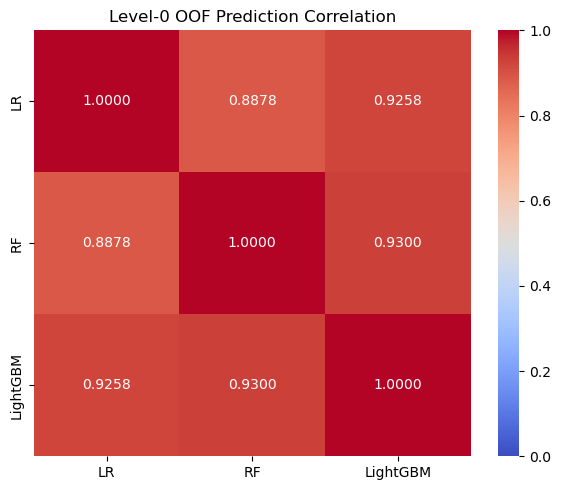


Most correlated pair: ('RF', 'LightGBM') (0.9300)
Least correlated pair: ('LR', 'RF') (0.8878)

2-model stack (RF + LightGBM) AUC: 0.8668
Full 3-model stack AUC (from Q2): 0.8713
Difference: -0.0045

5-model stack (LR+RF+LightGBM+KNN+XGBoost) AUC: 0.8716
Full 3-model stack AUC (from Q2): 0.8713
Difference: +0.0003


In [7]:
# ── Q3: Diversity analysis ────────────────────────────────────────────────
# Measure diversity of Level-0 OOF predictions:
#   1. Compute Pearson correlation matrix of OOF predictions (3x3)
#   2. Visualize as heatmap
#   3. Which pair of models is most correlated? Least correlated?
#   4. Build a stacked model using ONLY the two most correlated models as Level-0
#   5. Compare its AUC to the full 3-model stack
#   6. Does removing a correlated model hurt performance?
#   7. Build a stack using 5 models (add KNN + XGBoost) — does more models help?

import seaborn as sns
import xgboost as xgb
from sklearn.base import clone

# ── 1-2: Correlation matrix + heatmap of the 3 Level-0 OOF predictions ─────
oof_df = pd.DataFrame(oof_matrix, columns=model_names)
corr_matrix_q3 = oof_df.corr()
print(corr_matrix_q3.round(4))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix_q3, annot=True, fmt='.4f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Level-0 OOF Prediction Correlation')
plt.tight_layout()
plt.show()

# ── 3: Most / least correlated pair ────────────────────────────────────────
corr_pairs = corr_matrix_q3.where(np.triu(np.ones(corr_matrix_q3.shape), k=1).astype(bool)).stack()
most_correlated_pair = corr_pairs.idxmax()
least_correlated_pair = corr_pairs.idxmin()
print(f"\nMost correlated pair: {most_correlated_pair} ({corr_pairs.max():.4f})")
print(f"Least correlated pair: {least_correlated_pair} ({corr_pairs.min():.4f})")

# ── Reusable helper: build + evaluate an OOF stack for any set of Level-0 models ─
def build_and_evaluate_stack(level0_dict, X_train, y_train, X_holdout, y_holdout, cv):
    names = list(level0_dict.keys())
    oof = np.zeros((X_train.shape[0], len(names)))
    for col_idx, name in enumerate(names):
        for tr_idx, val_idx in cv.split(X_train, y_train):
            m = clone(level0_dict[name])
            m.fit(X_train[tr_idx], y_train[tr_idx])
            oof[val_idx, col_idx] = m.predict_proba(X_train[val_idx])[:, 1]

    meta = LogisticRegression(max_iter=1000, random_state=420)
    meta.fit(oof, y_train)

    test_preds = np.zeros((X_holdout.shape[0], len(names)))
    for col_idx, name in enumerate(names):
        m = clone(level0_dict[name])
        m.fit(X_train, y_train)
        test_preds[:, col_idx] = m.predict_proba(X_holdout)[:, 1]

    stacked = meta.predict_proba(test_preds)[:, 1]
    return roc_auc_score(y_holdout, stacked)

# ── 4-6: Stack using ONLY the two most correlated models ──────────────────
two_model_dict = {name: level0_models[name] for name in most_correlated_pair}
two_model_auc = build_and_evaluate_stack(two_model_dict, X_train, y_train, X_holdout, y_holdout, cv5)

print(f"\n2-model stack ({most_correlated_pair[0]} + {most_correlated_pair[1]}) AUC: {two_model_auc:.4f}")
print(f"Full 3-model stack AUC (from Q2): {stacked_auc:.4f}")
print(f"Difference: {two_model_auc - stacked_auc:+.4f}")

# ── 7: 5-model stack — add KNN + XGBoost ───────────────────────────────────
five_model_dict = {
    **level0_models,
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=420, eval_metric='logloss'),
}
five_model_auc = build_and_evaluate_stack(five_model_dict, X_train, y_train, X_holdout, y_holdout, cv5)

print(f"\n5-model stack (LR+RF+LightGBM+KNN+XGBoost) AUC: {five_model_auc:.4f}")
print(f"Full 3-model stack AUC (from Q2): {stacked_auc:.4f}")
print(f"Difference: {five_model_auc - stacked_auc:+.4f}")


***Takeaway*** 

Removing "the most correlated pair" backfired — but not for the reason correlation alone would suggest. 

The 2-model stack (RF+LightGBM) dropped to 0.8668 because it happened to exclude LR, the single strongest individual model (and the one Level-1 trusted most, coefficient 3.44 in Q2) — not because RF/LightGBM's correlation was inherently harmful. 

This is the real lesson: correlation tells you about redundancy, not about which model is safe to drop — you have to weigh a model's correlation against its individual quality, not prune by correlation alone. 

Meanwhile, the 5-model stack (adding KNN+XGBoost) gained essentially nothing (+0.0003, noise-level) — confirming diminishing returns kick in fast once we already have a reasonably strong, moderately diverse trio; more models isn't automatically more signal, even when one of the additions (XGBoost) is individually strong.

In [8]:
# ── Q4: Blending vs stacking ──────────────────────────────────────────────
# Compare blending (20% holdout) vs OOF stacking (5-fold) on the same data:
#   Blending:
#     - Train Level-0 on 80% of training set
#     - Generate predictions on 20% holdout
#     - Train Level-1 on those predictions
#     - Evaluate on test set
#
#   OOF Stacking:
#     - From Q2 above
#
# Compare: final test AUC, Level-1 training set size, total training time
# When would you choose blending over stacking?

import time
from sklearn.base import clone

# ── Blending ────────────────────────────────────────────────────────────
t0 = time.time()

X_train_blend, X_val_blend, y_train_blend, y_val_blend = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=420
)

blend_level0_fitted = {}
val_matrix = np.zeros((X_val_blend.shape[0], len(model_names)))
for col_idx, name in enumerate(model_names):
    m = clone(level0_models[name])
    m.fit(X_train_blend, y_train_blend)
    blend_level0_fitted[name] = m
    val_matrix[:, col_idx] = m.predict_proba(X_val_blend)[:, 1]

blend_meta = LogisticRegression(max_iter=1000, random_state=420)
blend_meta.fit(val_matrix, y_val_blend)

blend_test_matrix = np.zeros((X_holdout.shape[0], len(model_names)))
for col_idx, name in enumerate(model_names):
    blend_test_matrix[:, col_idx] = blend_level0_fitted[name].predict_proba(X_holdout)[:, 1]

blend_test_proba = blend_meta.predict_proba(blend_test_matrix)[:, 1]
blend_auc = roc_auc_score(y_holdout, blend_test_proba)

blend_time = time.time() - t0
blend_level1_train_size = X_val_blend.shape[0]

# ── OOF Stacking (retimed fresh here, for a fair head-to-head comparison) ──
t0 = time.time()

oof_matrix_q4 = np.zeros((X_train.shape[0], len(model_names)))
for col_idx, name in enumerate(model_names):
    for tr_idx, val_idx in cv5.split(X_train, y_train):
        m = clone(level0_models[name])
        m.fit(X_train[tr_idx], y_train[tr_idx])
        oof_matrix_q4[val_idx, col_idx] = m.predict_proba(X_train[val_idx])[:, 1]

stack_meta = LogisticRegression(max_iter=1000, random_state=420)
stack_meta.fit(oof_matrix_q4, y_train)

stack_test_matrix = np.zeros((X_holdout.shape[0], len(model_names)))
for col_idx, name in enumerate(model_names):
    m = clone(level0_models[name])
    m.fit(X_train, y_train)
    stack_test_matrix[:, col_idx] = m.predict_proba(X_holdout)[:, 1]

stack_test_proba = stack_meta.predict_proba(stack_test_matrix)[:, 1]
stack_auc_q4 = roc_auc_score(y_holdout, stack_test_proba)

stack_time = time.time() - t0
stack_level1_train_size = X_train.shape[0]

# ── Comparison ─────────────────────────────────────────────────────────────
comparison_q4 = pd.DataFrame({
    'Blending': {
        'Test AUC': blend_auc, 'Level-1 train size': blend_level1_train_size, 'Total time (s)': blend_time,
    },
    'OOF Stacking': {
        'Test AUC': stack_auc_q4, 'Level-1 train size': stack_level1_train_size, 'Total time (s)': stack_time,
    },
}).T
print(comparison_q4.round(4))


              Test AUC  Level-1 train size  Total time (s)
Blending        0.8711              1127.0          3.5973
OOF Stacking    0.8713              5634.0         20.3709


***Takeaway***

Blending and stacking landed at essentially the same AUC (0.8711 vs 0.8713, pure noise), but blending got there with 5x less data and 5.7x less time (3.6s vs 20.4s). 

Stacking's "uses more data" advantage never paid off here because the meta-learner (3-input Logistic Regression) was simple enough that 1,127 rows was already plenty. 

Practical takeaway: for a lightweight meta-learner like this, blending is the pragmatic choice — same result, far cheaper.